In [1]:
import geopandas as gpd 
import shapely 
from shapely.geometry import Point, LineString, Polygon, MultiPolygon

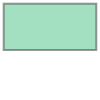

In [2]:
#Define the top of the car
top = Polygon([(0,0), (0,1),(2,1),(2,0)])
top

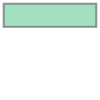

In [3]:
bottom = Polygon([(-1,0),(3,0),(3,-1),(-1,-1)])
bottom

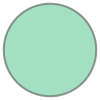

In [4]:
wheel_front = Point((0,-1.5)).buffer(0.5)
wheel_back = Point((2,-1.5)).buffer(0.5)
wheel_front

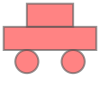

In [5]:
car = MultiPolygon([top,bottom,wheel_front,wheel_back])
car

In [6]:
car.length

22.28066231390951

In [7]:
car.area

7.56827424527297

In [ ]:
# Define the top of the car
top = Polygon([(0, 1), (0, 2), (2, 2), (2, 1)])
top

# Define the bottom part of the car
bottom = Polygon([(-1, 0), (-1, 1), (4, 1), (4, 0)])
bottom

# Create the wheels with a radius of 0.5 each
wheel_front = Point(0, -0.5).buffer(0.5)
wheel_rear = Point(3, -0.5).buffer(0.5)
wheel_rear

# Combine the shapes to form the car
geometries = [top, bottom, wheel_front, wheel_rear]
geometries


#Create a GeoDataFrame
gdf = gpd.GeoDataFrame(geometry = geometries)
gdf.crs = 4326
display(gdf)


,geometry
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))"
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))"
2,"POLYGON ((0.5 -0.5, 0.49759 -0.54901, 0.49039 ..."
3,"POLYGON ((3.5 -0.5, 3.49759 -0.54901, 3.49039 ..."


In [13]:
gdf['geometry_length'] = gdf.length 
gdf['geometry_area'] = gdf.area

gdf.head()

C:\Users\muzic\AppData\Local\Temp\ipykernel_11824\3973972505.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_length'] = gdf.length
C:\Users\muzic\AppData\Local\Temp\ipykernel_11824\3973972505.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_area'] = gdf.area


,geometry,geometry_length,geometry_area
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))",6.000000,2.000000
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))",12.000000,5.000000
2,"POLYGON ((0.5 -0.5, 0.49759 -0.54901, 0.49039 ...",3.140331,0.784137
3,"POLYGON ((3.5 -0.5, 3.49759 -0.54901, 3.49039 ...",3.140331,0.784137


In [14]:
#Add a new column for geometry area
gdf['geometry'] = [g.buffer(0.2) for g in gdf.geometry.to_list()]
gdf.head()

,geometry,geometry_length,geometry_area
0,"POLYGON ((0 0.8, -0.0196 0.80096, -0.03902 0.8...",6.000000,2.000000
1,"POLYGON ((-1 -0.2, -1.0196 -0.19904, -1.03902 ...",12.000000,5.000000
2,"POLYGON ((0.69976 -0.49019, 0.69976 -0.50981, ...",3.140331,0.784137
3,"POLYGON ((3.69976 -0.49019, 3.69976 -0.50981, ...",3.140331,0.784137


<Axes: >

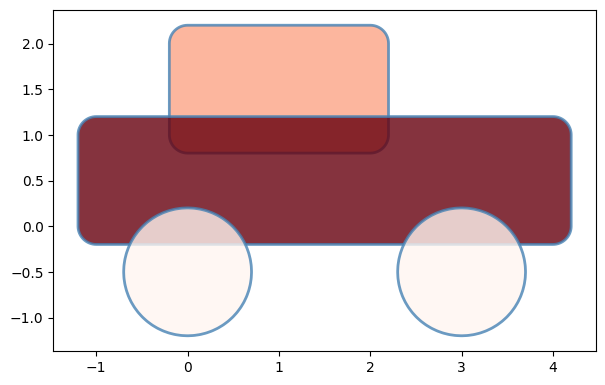

In [16]:
#Visualize the data
import matplotlib.pyplot as plt
f, ax = plt.subplots(1,1,figsize=(7,7))
gdf.plot(column='geometry_length',ax=ax,cmap='Reds',edgecolor='steelblue',linewidth=2,alpha=0.8)

In [17]:
#create new projections
gdf_nyc = gdf.to_crs(epsg=2263)
gdf_hun = gdf.to_crs(epsg=23700)

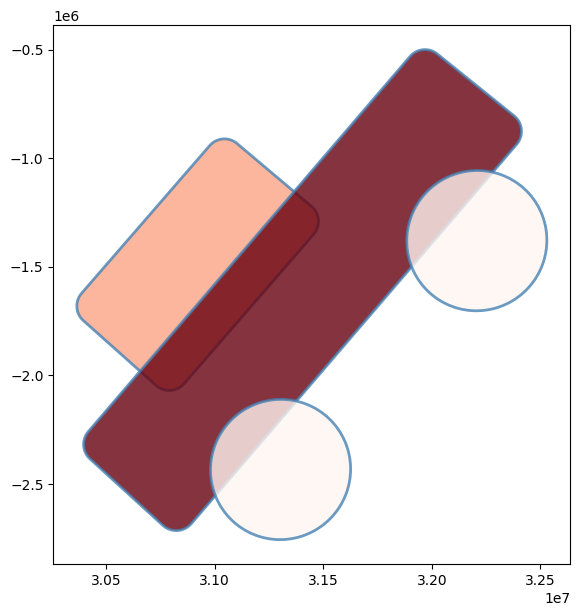

In [18]:
f, ax = plt.subplots(1,1,figsize=(7,7))
gdf_nyc.plot(column='geometry_length',ax=ax,cmap='Reds',edgecolor='steelblue',linewidth=2,alpha=0.8)
plt.show()

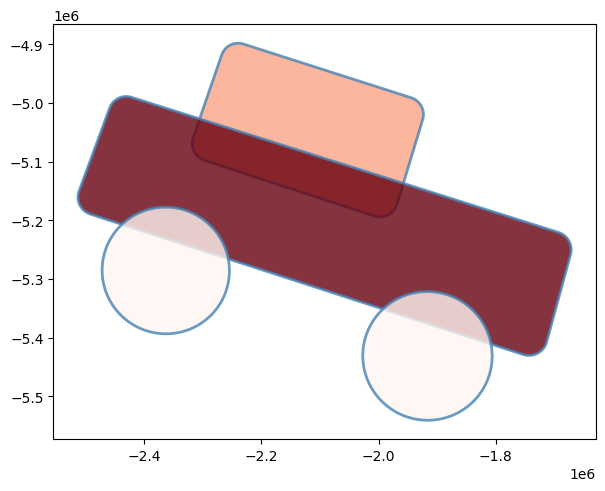

In [19]:
f, ax = plt.subplots(1,1,figsize=(7,7))
gdf_hun.plot(column='geometry_length',ax=ax,cmap='Reds',edgecolor='steelblue',linewidth=2,alpha=0.8)
plt.show()